# Fusión multimodal — TabNet + TFT + Bio_ClinicalBERT

Cuaderno del modelo de fusión multimodal del TFM. Integra las representaciones de los
tres codificadores especializados, entrenados en los cuadernos 07–09 y cargados aquí
**congelados** (no se reentrenan):

```
tab  ← TabNet.encoder(x_99)          [32]   (cuaderno 07)
tft  ← SepsisTFT.encode(seq, static) [64]   (cuaderno 08)
bert ← Bio_ClinicalBERT [CLS]        [768]  (cuaderno 09)
```

La fusión emplea **cross-modal attention direccional** (estilo MulT): para cada modalidad A,
la *query* procede de A y las *keys/values* de las otras dos.

```
tab_enriched  = CrossAttn(Q=tab,  K/V=[tft, bert])
tft_enriched  = CrossAttn(Q=tft,  K/V=[tab, bert])
bert_enriched = CrossAttn(Q=bert, K/V=[tab, tft])
```

Al final del cuaderno se incluye la **ablación de la rama tabular**: la misma red, con
idénticos hiperparámetros y semilla, entrenada con el vector de 99 características sin
comprimir en lugar de la representación del codificador de TabNet.


In [1]:
import os
# GPU habilitada (CUDA 12.8): ya no se oculta el dispositivo

import polars as pl
import numpy as np
import json
import pickle
from pathlib import Path
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

MIMIC    = Path.home() / "mimic-iv-3.0"
HOSP     = MIMIC / "hosp"
PROC     = Path("../data/processed")
TFT_DIR  = Path("../experiments/tft")
BERT_DIR = Path("../experiments/clinicalbert")
TABNET_DIR = Path("../experiments/tabnet")
OUT_DIR  = Path("../experiments/fusion_multimodal")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 24

torch.manual_seed(SEED)
np.random.seed(SEED)

def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}")

print(f"Device: {DEVICE}")

Device: cuda


## Preparación de datos
Cohorte Sepsis-3, horizontes de predicción (6h y 12h) y características tabulares:
las mismas 99 variables de ventana con las que se entrenaron XGBoost y TabNet.

In [2]:
log("Cargando cohorte ...")
cohort = pl.read_parquet(PROC / "cohort.parquet").select(
    ["subject_id", "stay_id", "los_hours", "sepsis"]
)
splits = pl.read_parquet(PROC / "splits.parquet").select(["stay_id", "split"])
cohort = cohort.join(splits, on="stay_id", how="left")
vitals_meta = (
    pl.read_parquet(PROC / "vitals/vitals_hourly.parquet",
                    columns=["stay_id", "onset_hour"])
    .unique(subset=["stay_id"])
)
cohort = cohort.join(vitals_meta, on="stay_id", how="left")
patients = pl.read_csv(
    HOSP / "patients.csv.gz", columns=["subject_id", "gender", "anchor_age"]
).with_columns((pl.col("gender") == "M").cast(pl.Int8).alias("male"))
cohort = cohort.join(
    patients.select(["subject_id", "anchor_age", "male"]), on="subject_id", how="left"
)

def assign_ref_hour(cohort, horizon, seed):
    rng = np.random.default_rng(seed)
    out = []
    for r in cohort.to_dicts():
        if r["sepsis"] == 1:
            ref = (int(r["onset_hour"]) - horizon) if r["onset_hour"] is not None else None
        else:
            lo, hi = 24, int(r["los_hours"]) - horizon
            ref = int(rng.integers(lo, hi + 1)) if hi >= lo else None
        if ref is not None and ref >= 12:
            r["ref_hour"] = ref
            out.append(r)
    return pl.DataFrame(out)

cohort_6h  = assign_ref_hour(cohort, 6,  SEED)
cohort_12h = assign_ref_hour(cohort, 12, SEED + 1)
print(f"Stays válidos 6h: {len(cohort_6h):,}  |  12h: {len(cohort_12h):,}")

[12:55:53] Cargando cohorte ...


Stays válidos 6h: 53,453  |  12h: 47,219


In [3]:
log("Cargando vitales y labs ...")
VITAL_COLS = ["heart_rate", "resp_rate", "spo2", "map", "temp_c", "fio2", "gcs_total"]
LAB_COLS   = ["platelet", "bilirubin", "creatinine", "lactate", "wbc",
              "hemoglobin", "sodium", "potassium", "glucose",
              "bicarbonate", "bun", "albumin", "inr", "ph", "pao2"]
vitals = pl.read_parquet(PROC / "vitals/vitals_hourly.parquet",
                         columns=["stay_id", "hours_from_intime"] + VITAL_COLS)
labs   = pl.read_parquet(PROC / "labs/labs_hourly.parquet",
                         columns=["stay_id", "hours_from_intime"] + LAB_COLS)

def window_stats(data, ref, value_cols):
    windowed = (
        data.join(ref.select(["stay_id", "ref_hour"]), on="stay_id", how="inner")
        .filter(
            (pl.col("hours_from_intime") <= pl.col("ref_hour")) &
            (pl.col("hours_from_intime") >= pl.col("ref_hour") - 24)
        ).sort("hours_from_intime")
    )
    agg = []
    for c in value_cols:
        if c not in windowed.columns: continue
        agg += [
            pl.col(c).last().alias(f"{c}_last"),
            pl.col(c).mean().alias(f"{c}_mean"),
            (pl.col(c).last() - pl.col(c).first()).alias(f"{c}_trend"),
            (pl.col(c).max() - pl.col(c).min()).alias(f"{c}_range"),
        ]
    return windowed.group_by("stay_id").agg(agg)

def extract_features(cohort_h):
    vf = window_stats(vitals, cohort_h, VITAL_COLS)
    lf = window_stats(labs,   cohort_h, LAB_COLS)
    qsofa = (
        vf.select(["stay_id", "resp_rate_last", "map_last", "gcs_total_last"])
        .with_columns([
            (pl.col("resp_rate_last") >= 22).cast(pl.Int8).fill_null(0).alias("qsofa_rr"),
            (pl.col("map_last") <= 70).cast(pl.Int8).fill_null(0).alias("qsofa_map"),
            (pl.col("gcs_total_last") < 15).cast(pl.Int8).fill_null(0).alias("qsofa_gcs"),
        ])
        .with_columns(
            (pl.col("qsofa_rr") + pl.col("qsofa_map") + pl.col("qsofa_gcs")).alias("qsofa")
        ).select(["stay_id", "qsofa", "qsofa_rr", "qsofa_map", "qsofa_gcs"])
    )
    sirs = (
        vf.select(["stay_id", "temp_c_last", "heart_rate_last", "resp_rate_last"])
        .join(lf.select(["stay_id", "wbc_last"]), on="stay_id", how="left")
        .with_columns([
            ((pl.col("temp_c_last") > 38) | (pl.col("temp_c_last") < 36))
            .cast(pl.Int8).fill_null(0).alias("sirs_temp"),
            (pl.col("heart_rate_last") > 90).cast(pl.Int8).fill_null(0).alias("sirs_hr"),
            (pl.col("resp_rate_last") > 20).cast(pl.Int8).fill_null(0).alias("sirs_rr"),
            ((pl.col("wbc_last") > 12) | (pl.col("wbc_last") < 4))
            .cast(pl.Int8).fill_null(0).alias("sirs_wbc"),
        ])
        .with_columns(
            (pl.col("sirs_temp") + pl.col("sirs_hr") + pl.col("sirs_rr") + pl.col("sirs_wbc"))
            .alias("sirs")
        ).select(["stay_id", "sirs", "sirs_temp", "sirs_hr", "sirs_rr", "sirs_wbc"])
    )
    return (
        cohort_h.select(["stay_id", "subject_id", "split", "sepsis", "ref_hour", "anchor_age", "male"])
        .join(vf, on="stay_id", how="left").join(lf, on="stay_id", how="left")
        .join(qsofa, on="stay_id", how="left").join(sirs, on="stay_id", how="left")
    )

META_COLS = ["stay_id", "subject_id", "split", "sepsis", "ref_hour"]
log("Extrayendo features tabulares 6h ..."); feats_6h  = extract_features(cohort_6h)
log("Extrayendo features tabulares 12h ..."); feats_12h = extract_features(cohort_12h)
FEATURE_COLS = [c for c in feats_6h.columns if c not in META_COLS]
print(f"Features tabulares: {len(FEATURE_COLS)}")

# Comprobación: el vector tabular debe coincidir con el que se usó para entrenar TabNet.
with open(TABNET_DIR / "results.json") as f:
    _tabnet_res = json.load(f)
assert len(FEATURE_COLS) == _tabnet_res["n_features"], (
    f"Desajuste de características: fusión={len(FEATURE_COLS)} "
    f"vs TabNet entrenado={_tabnet_res['n_features']}"
)
print(f"OK: {len(FEATURE_COLS)} características, coinciden con las de TabNet.")

[12:55:53] Cargando vitales y labs ...
[12:55:54] Extrayendo features tabulares 6h ...


[12:55:54] Extrayendo features tabulares 12h ...


Features tabulares: 99
OK: 99 características, coinciden con las de TabNet.


## Representaciones del TFT (64 dim)

Se reconstruye la arquitectura del cuaderno 08, se cargan los pesos entrenados y se
extrae la representación pre-clasificador (último *timestep*) para cada estancia.

In [4]:
class GRN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.gate = nn.Linear(hidden_dim, output_dim)
        self.skip = nn.Linear(input_dim, output_dim) if input_dim != output_dim else nn.Identity()
        self.ln = nn.LayerNorm(output_dim)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        h = F.elu(self.fc1(x)); h = self.drop(h)
        return self.ln(torch.sigmoid(self.gate(h)) * self.fc2(h) + self.skip(x))

class VSN(nn.Module):
    def __init__(self, n_vars, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.var_grns = nn.ModuleList([GRN(input_dim, hidden_dim, hidden_dim, dropout) for _ in range(n_vars)])
        self.weight_grn = GRN(n_vars * input_dim, hidden_dim, n_vars, dropout)
    def forward(self, x):
        flat = x.reshape(*x.shape[:-2], -1)
        w = torch.softmax(self.weight_grn(flat), dim=-1)
        proc = torch.stack([grn(x[..., i, :]) for i, grn in enumerate(self.var_grns)], dim=-2)
        return (w.unsqueeze(-1) * proc).sum(dim=-2), w

class SepsisTFT(nn.Module):
    def __init__(self, n_vitals=7, n_static=2, hidden_dim=64, n_heads=4, n_lstm_layers=2, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.vital_embeds  = nn.ModuleList([nn.Linear(1, hidden_dim) for _ in range(n_vitals)])
        self.static_embeds = nn.ModuleList([nn.Linear(1, hidden_dim) for _ in range(n_static)])
        self.vsn_temporal = VSN(n_vitals, hidden_dim, hidden_dim, dropout)
        self.vsn_static   = VSN(n_static, hidden_dim, hidden_dim, dropout)
        self.static_ctx_h = nn.Linear(hidden_dim, hidden_dim)
        self.static_ctx_c = nn.Linear(hidden_dim, hidden_dim)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, n_lstm_layers,
                            dropout=dropout if n_lstm_layers > 1 else 0., batch_first=True)
        self.post_lstm_grn = GRN(hidden_dim, hidden_dim, hidden_dim, dropout)
        self.attn = nn.MultiheadAttention(hidden_dim, n_heads, dropout=dropout, batch_first=True)
        self.post_attn_grn = GRN(hidden_dim, hidden_dim, hidden_dim, dropout)
        self.classifier = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Dropout(dropout), nn.Linear(hidden_dim, 1))

    def encode(self, seq, static):
        B, T, V = seq.shape
        vital_emb  = torch.stack([self.vital_embeds[i](seq[..., i:i+1])  for i in range(V)], dim=2)
        static_emb = torch.stack([self.static_embeds[i](static[..., i:i+1]) for i in range(static.shape[-1])], dim=1)
        static_sel, _ = self.vsn_static(static_emb)
        temp_sel,   _ = self.vsn_temporal(vital_emb)
        h0 = self.static_ctx_h(static_sel).unsqueeze(0).expand(self.lstm.num_layers, -1, -1).contiguous()
        c0 = self.static_ctx_c(static_sel).unsqueeze(0).expand(self.lstm.num_layers, -1, -1).contiguous()
        lstm_out, _ = self.lstm(temp_sel, (h0, c0))
        lstm_out = self.post_lstm_grn(lstm_out)
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)
        return self.post_attn_grn(attn_out)[:, -1, :]

    def forward(self, seq, static):
        rep = self.encode(seq, static)
        return self.classifier(rep).squeeze(-1), rep


def extract_tft_repr(model, cohort_h, vitals, vital_cols, seq_len, imp, sc, imp_st, sc_st, split_name):
    subset  = cohort_h.filter(pl.col("split") == split_name)
    records = subset.select(["stay_id", "ref_hour", "anchor_age", "male"]).to_dicts()
    split_ids = subset["stay_id"].to_list()
    vitals_split = vitals.filter(pl.col("stay_id").is_in(split_ids)).sort(["stay_id", "hours_from_intime"])
    vitals_by_stay = {sid[0]: grp.select(vital_cols).to_pandas().astype(float).values
                      for sid, grp in vitals_split.group_by("stay_id")}
    hours_by_stay  = {sid[0]: grp["hours_from_intime"].to_numpy()
                      for sid, grp in vitals_split.group_by("stay_id")}
    n = len(records)
    seqs = np.zeros((n, seq_len, len(vital_cols)), dtype=np.float32)
    statics = np.zeros((n, 2), dtype=np.float32)
    for i, r in enumerate(records):
        sid, ref = r["stay_id"], r["ref_hour"]
        if sid in vitals_by_stay:
            hours = hours_by_stay[sid]
            mask  = (hours >= ref - seq_len) & (hours <= ref)
            win   = vitals_by_stay[sid][mask]
            if len(win) > 0:
                w = sc.transform(imp.transform(win)).astype(np.float32)
                n_rows = min(len(w), seq_len)
                seqs[i, -n_rows:] = w[-n_rows:]
        static_raw = np.array([[r["anchor_age"] or 0., r["male"] or 0.]])
        statics[i] = sc_st.transform(imp_st.transform(static_raw))[0]
    seq_t, stat_t = torch.from_numpy(seqs), torch.from_numpy(statics)
    model.eval()
    reprs = []
    with torch.no_grad():
        for i in range(0, n, 512):
            reprs.append(model.encode(seq_t[i:i+512], stat_t[i:i+512]).numpy())
    return np.array([r["stay_id"] for r in records]), np.concatenate(reprs, axis=0)


with open(TFT_DIR / "model_params.json") as f: tft_params = json.load(f)

log("Extrayendo representaciones TFT — 6h ...")
with open(TFT_DIR / "scalers_6h.pkl", "rb") as f: imp6, sc6, imp6_st, sc6_st = pickle.load(f)
tft_model_6h = SepsisTFT(**tft_params)
tft_model_6h.load_state_dict(torch.load(TFT_DIR / "tft_6h.pt", map_location="cpu"))
tft_ids_6h, tft_repr_6h = {}, {}
for split in ["train", "val", "test"]:
    ids, rep = extract_tft_repr(tft_model_6h, cohort_6h, vitals, VITAL_COLS, SEQ_LEN, imp6, sc6, imp6_st, sc6_st, split)
    tft_ids_6h[split], tft_repr_6h[split] = ids, rep
    print(f"  6h {split}: {rep.shape}")

log("Extrayendo representaciones TFT — 12h ...")
with open(TFT_DIR / "scalers_12h.pkl", "rb") as f: imp12, sc12, imp12_st, sc12_st = pickle.load(f)
tft_model_12h = SepsisTFT(**tft_params)
tft_model_12h.load_state_dict(torch.load(TFT_DIR / "tft_12h.pt", map_location="cpu"))
tft_ids_12h, tft_repr_12h = {}, {}
for split in ["train", "val", "test"]:
    ids, rep = extract_tft_repr(tft_model_12h, cohort_12h, vitals, VITAL_COLS, SEQ_LEN, imp12, sc12, imp12_st, sc12_st, split)
    tft_ids_12h[split], tft_repr_12h[split] = ids, rep
    print(f"  12h {split}: {rep.shape}")

[12:55:54] Extrayendo representaciones TFT — 6h ...


  6h train: (37376, 64)


  6h val: (8061, 64)


  6h test: (8016, 64)
[12:56:26] Extrayendo representaciones TFT — 12h ...


  12h train: (32992, 64)


  12h val: (7127, 64)


  12h test: (7100, 64)


## Representaciones de TabNet (32 dim)

TabNet no expone directamente su representación latente, pero la capa `final_mapping`
(`Linear(in_features=32, out_features=2)`) recibe justamente el vector que buscamos: la
salida agregada de los 5 pasos de atención, antes del clasificador. Se captura con un
*forward hook*.

La correspondencia se verifica comprobando que `z @ W_final.T` reproduce los logits del
modelo, lo que garantiza que `z` es exactamente la representación pre-clasificador y no
un tensor intermedio cualquiera.

Los embeddings se estandarizan (media/desviación del conjunto de entrenamiento) antes de
entrar en la fusión, para que las tres modalidades lleguen en escalas comparables.

In [5]:
from pytorch_tabnet.tab_model import TabNetClassifier

TABNET_DIM = 32


def load_tabnet(horizon):
    clf = TabNetClassifier()
    clf.load_model(str(TABNET_DIR / f"tabnet_{horizon}.zip"))
    with open(TABNET_DIR / f"preprocessor_{horizon}.pkl", "rb") as f:
        imp_tn, sc_tn = pickle.load(f)
    clf.network.eval()
    return clf, imp_tn, sc_tn


def extract_tabnet_repr(clf, X_raw, batch_size=1024, check=False):
    """Representación de 32 dim de TabNet: la entrada de `final_mapping`."""
    buf = {}
    handle = clf.network.tabnet.final_mapping.register_forward_hook(
        lambda mod, inp, out: buf.__setitem__("z", inp[0].detach().cpu())
    )
    reprs, logits = [], []
    try:
        with torch.no_grad():
            for i in range(0, len(X_raw), batch_size):
                xb = torch.from_numpy(X_raw[i:i + batch_size]).to(clf.device)
                out = clf.network(xb)
                reprs.append(buf["z"].numpy())
                logits.append(out[0].detach().cpu().numpy())
    finally:
        handle.remove()
    Z = np.concatenate(reprs, axis=0).astype(np.float32)
    if check:
        W = clf.network.tabnet.final_mapping.weight.detach().cpu().numpy()
        err = np.abs(Z @ W.T - np.concatenate(logits, axis=0)).max()
        assert err < 1e-3, f"La representación no reproduce los logits (err={err:.2e})"
        print(f"  verificación z @ W.T ≈ logits: error máx = {err:.2e}")
    return Z


log("Cargando modelos TabNet entrenados ...")
tabnet_6h,  imp_tn6,  sc_tn6  = load_tabnet("6h")
tabnet_12h, imp_tn12, sc_tn12 = load_tabnet("12h")
print(f"  TabNet 6h/12h cargados  |  n_d={tabnet_6h.n_d}  n_steps={tabnet_6h.n_steps}")

[12:56:54] Cargando modelos TabNet entrenados ...


/home/fer/miniconda3/envs/sepsis-tfm/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


  TabNet 6h/12h cargados  |  n_d=32  n_steps=5


In [6]:
BERT_DIM = 768


def load_bert_lookup(horizon):
    lookup = {}
    for split in ["train", "val", "test"]:
        ids  = np.load(BERT_DIR / f"stay_ids_{horizon}_{split}.npy")
        embs = np.load(BERT_DIR / f"cls_{horizon}_{split}.npy")
        for sid, emb in zip(ids, embs):
            lookup[int(sid)] = emb
    return lookup


bert_lookup_6h  = load_bert_lookup("6h")
bert_lookup_12h = load_bert_lookup("12h")


def get_bert_arrays(stay_ids, lookup):
    embs     = np.zeros((len(stay_ids), BERT_DIM), dtype=np.float32)
    has_note = np.zeros(len(stay_ids), dtype=np.float32)
    for i, sid in enumerate(stay_ids):
        if int(sid) in lookup:
            embs[i]     = lookup[int(sid)]
            has_note[i] = 1.0
    return embs, has_note


def build_fusion_dataset(feats_df, tft_ids, tft_repr, bert_lookup, feature_cols,
                         tabnet_clf, imp_tn, sc_tn):
    """
    Ensambla los tensores de fusión por partición. La rama tabular es la
    representación de 32 dim del codificador de TabNet.
    """
    tab_lookup   = {r.pop("stay_id"): np.array(
        [r[c] if r[c] is not None else np.nan for c in feature_cols], dtype=float)
        for r in feats_df.select(["stay_id"] + feature_cols).to_dicts()}
    label_lookup = dict(zip(feats_df["stay_id"].to_list(), feats_df["sepsis"].to_list()))

    # 1) Vector crudo por split, con el preprocesador con el que se entrenó TabNet
    raw = {}
    for split in ["train", "val", "test"]:
        ids = tft_ids[split]
        X_raw = np.stack([tab_lookup.get(int(sid), np.full(len(feature_cols), np.nan))
                          for sid in ids])
        raw[split] = sc_tn.transform(imp_tn.transform(X_raw)).astype(np.float32)

    # 2) Codificador de TabNet -> 32 dim
    Z = {}
    for split in ["train", "val", "test"]:
        Z[split] = extract_tabnet_repr(tabnet_clf, raw[split], check=(split == "train"))

    # 3) Estandarizar los embeddings con estadísticos de train (sin fuga)
    sc_emb = StandardScaler().fit(Z["train"])

    result = {}
    for split in ["train", "val", "test"]:
        ids = tft_ids[split]
        X_tab  = sc_emb.transform(Z[split]).astype(np.float32)
        X_tft  = tft_repr[split].astype(np.float32)
        X_bert, has_note = get_bert_arrays(ids, bert_lookup)
        y = np.array([label_lookup.get(int(sid), 0) for sid in ids], dtype=np.int64)
        result[split] = (X_tab, X_tft, X_bert, has_note, y)
        print(f"  {split}: n={len(ids):,}  sep={y.sum():,}  has_note={has_note.sum():.0f}  "
              f"tab={X_tab.shape[1]}d  tft={X_tft.shape[1]}d  bert={X_bert.shape[1]}d")
    return result, sc_emb


log("Ensamblando datasets de fusión (rama tabular = codificador TabNet) ...")
print("6h:")
fusion_6h,  sc_emb6  = build_fusion_dataset(
    feats_6h,  tft_ids_6h,  tft_repr_6h,  bert_lookup_6h,  FEATURE_COLS,
    tabnet_6h, imp_tn6, sc_tn6)
print("12h:")
fusion_12h, sc_emb12 = build_fusion_dataset(
    feats_12h, tft_ids_12h, tft_repr_12h, bert_lookup_12h, FEATURE_COLS,
    tabnet_12h, imp_tn12, sc_tn12)

[12:56:55] Ensamblando datasets de fusión (rama tabular = codificador TabNet) ...
6h:


  verificación z @ W.T ≈ logits: error máx = 7.63e-06
  train: n=37,376  sep=3,047  has_note=28406  tab=32d  tft=64d  bert=768d
  val: n=8,061  sep=686  has_note=6132  tab=32d  tft=64d  bert=768d


  test: n=8,016  sep=690  has_note=6050  tab=32d  tft=64d  bert=768d
12h:


  verificación z @ W.T ≈ logits: error máx = 5.72e-06
  train: n=32,992  sep=2,728  has_note=25175  tab=32d  tft=64d  bert=768d
  val: n=7,127  sep=617  has_note=5420  tab=32d  tft=64d  bert=768d
  test: n=7,100  sep=630  has_note=5376  tab=32d  tft=64d  bert=768d


## Arquitectura de fusión

Un bloque de *cross-modal attention* por modalidad (Q = propia, K/V = las otras dos),
cada uno con FFN y conexiones residuales, y un clasificador MLP sobre la concatenación
de las tres representaciones enriquecidas.

In [7]:
class CrossModalAttentionBlock(nn.Module):
    """
    Q de la modalidad propia, K/V de las otras dos.
    Con n_heads cabezas y una sola secuencia de 2 tokens como K/V,
    la atención aprende a ponderar cada modalidad fuente por cabeza.
    """
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )
        self.norm = nn.LayerNorm(d_model)
        self.ffn  = nn.Sequential(
            nn.Linear(d_model, d_model * 2), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(d_model * 2, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, query_modal, other_modals):
        """
        query_modal:  [B, d_model]  — modalidad que genera la query
        other_modals: list of [B, d_model]  — las otras 2 modalidades (K/V)
        """
        q  = query_modal.unsqueeze(1)                      # [B, 1, d_model]
        kv = torch.stack(other_modals, dim=1)              # [B, 2, d_model]
        attended, attn_w = self.attn(q, kv, kv)           # [B, 1, d_model]
        x = self.norm(attended.squeeze(1) + query_modal)  # residual
        x = self.norm2(self.ffn(x) + x)                   # FFN + residual
        return x, attn_w                                   # attn_w: [B, n_heads, 1, 2]


class TrueCrossModalFusion(nn.Module):
    """
    Cross-modal attention direccional para 3 modalidades.
    Cada modalidad genera su query y atiende a las otras dos como K/V.
    """
    def __init__(self, tab_dim=99, tft_dim=64, bert_dim=768,
                 d_model=128, n_heads=4, dropout=0.2):
        super().__init__()
        # Proyecciones de entrada
        self.proj_tab  = nn.Sequential(
            nn.Linear(tab_dim + 1, d_model), nn.LayerNorm(d_model), nn.ReLU()
        )  # +1 = has_note
        self.proj_tft  = nn.Sequential(
            nn.Linear(tft_dim,  d_model), nn.LayerNorm(d_model), nn.ReLU()
        )
        self.proj_bert = nn.Sequential(
            nn.Linear(bert_dim, d_model), nn.LayerNorm(d_model), nn.ReLU()
        )
        # Un bloque de cross-attention por modalidad (Q=self, K/V=others)
        self.ca_tab  = CrossModalAttentionBlock(d_model, n_heads, dropout)  # tab  ← {tft, bert}
        self.ca_tft  = CrossModalAttentionBlock(d_model, n_heads, dropout)  # tft  ← {tab, bert}
        self.ca_bert = CrossModalAttentionBlock(d_model, n_heads, dropout)  # bert ← {tab, tft}

        # Clasificador sobre representaciones enriquecidas concatenadas
        self.classifier = nn.Sequential(
            nn.Linear(3 * d_model, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, X_tab, X_tft, X_bert, has_note):
        # Proyectar cada modalidad a d_model
        tab_in  = torch.cat([X_tab, has_note.unsqueeze(-1)], dim=-1)
        h_tab  = self.proj_tab(tab_in)    # [B, d_model]
        h_tft  = self.proj_tft(X_tft)    # [B, d_model]
        h_bert = self.proj_bert(X_bert)  # [B, d_model]

        # Cross-modal attention: Q=self, K/V=otras dos
        h_tab_new,  w_tab  = self.ca_tab(h_tab,   [h_tft, h_bert])  # tab  ← tft, bert
        h_tft_new,  w_tft  = self.ca_tft(h_tft,   [h_tab, h_bert])  # tft  ← tab, bert
        h_bert_new, w_bert = self.ca_bert(h_bert,  [h_tab, h_tft])   # bert ← tab, tft

        # Clasificar sobre representaciones enriquecidas
        fused = torch.cat([h_tab_new, h_tft_new, h_bert_new], dim=-1)  # [B, 3*d_model]
        logit = self.classifier(fused).squeeze(-1)

        # Devolver pesos de atención de cada modalidad sobre las otras dos
        # w_tab: [B, n_heads, 1, 2] → [B, 2] promediando cabezas
        attn_weights = {
            "tab":  w_tab.mean(1).squeeze(1),    # [B, 2]: tab→(tft, bert)
            "tft":  w_tft.mean(1).squeeze(1),    # [B, 2]: tft→(tab, bert)
            "bert": w_bert.mean(1).squeeze(1),   # [B, 2]: bert→(tab, tft)
        }
        return logit, attn_weights


TAB_DIM  = TABNET_DIM   # 32 (codificador TabNet)
TFT_DIM  = 64

_m = TrueCrossModalFusion(TAB_DIM, TFT_DIM, BERT_DIM)
print(f"Parámetros fusión cross-modal direccional: {sum(p.numel() for p in _m.parameters()):,}")
del _m

Parámetros fusión cross-modal direccional: 558,977


## Entrenamiento

AdamW (lr=1e-3, wd=1e-4), ReduceLROnPlateau sobre el AUROC de validación, BCE ponderada
por `pos_weight`, parada anticipada por AUROC de validación y semilla fija.

Se entrenan **dos variantes** de la misma arquitectura, que difieren únicamente en cómo
entra la modalidad tabular:

1. **Rama tabular comprimida** por el codificador de TabNet a 32 dimensiones (esta sección).
2. **Rama tabular sin comprimir**: el vector de 99 características entra directamente en la
   proyección lineal que aprende la red de fusión (más abajo).

La segunda es **el sistema que adopta el TFM**; la primera se conserva como ablación,
porque es la comparación que justifica esa elección. Se entrenan en este orden por
motivos históricos del cuaderno; el orden no afecta a la conclusión, que se lee en la
comparativa del final.

In [8]:
def make_loaders(fusion_data, batch_size=512):
    loaders = {}
    for split, (X_tab, X_tft, X_bert, has_note, y) in fusion_data.items():
        ds = TensorDataset(
            torch.from_numpy(X_tab), torch.from_numpy(X_tft),
            torch.from_numpy(X_bert), torch.from_numpy(has_note),
            torch.from_numpy(y),
        )
        loaders[split] = DataLoader(ds, batch_size=batch_size, shuffle=(split == "train"))
    return loaders


def train_fusion(fusion_data, pos_weight_val, n_epochs=80, patience=12, lr=1e-3):
    loaders = make_loaders(fusion_data)
    tab_dim = fusion_data["train"][0].shape[1]
    model   = TrueCrossModalFusion(tab_dim, TFT_DIM, BERT_DIM).to(DEVICE)
    pos_w   = torch.tensor([pos_weight_val], dtype=torch.float32).to(DEVICE)
    crit    = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    opt     = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched   = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", patience=5, factor=0.5)

    best_auroc, best_state, patience_count = 0.0, None, 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        for X_tab, X_tft, X_bert, hn, labels in loaders["train"]:
            X_tab, X_tft, X_bert = X_tab.to(DEVICE), X_tft.to(DEVICE), X_bert.to(DEVICE)
            hn, labels = hn.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            logits, _ = model(X_tab, X_tft, X_bert, hn)
            crit(logits, labels.float()).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        probs, labs = [], []
        with torch.no_grad():
            for X_tab, X_tft, X_bert, hn, labels in loaders["val"]:
                logits, _ = model(X_tab.to(DEVICE), X_tft.to(DEVICE), X_bert.to(DEVICE), hn.to(DEVICE))
                probs.extend(torch.sigmoid(logits).cpu().numpy())
                labs.extend(labels.numpy())
        auroc = roc_auc_score(labs, probs)
        sched.step(auroc)

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d} | val AUROC={auroc:.4f}")

        if auroc > best_auroc:
            best_auroc = auroc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"  Early stopping en epoch {epoch}")
                break

    model.load_state_dict(best_state)
    print(f"  Mejor val AUROC: {best_auroc:.4f}")
    return model, best_auroc


def get_pw(fusion_data):
    y = fusion_data["train"][4]
    return float((y == 0).sum() / max((y == 1).sum(), 1))


models, val_auroc = {}, {}
for horizon, data in [("6h", fusion_6h), ("12h", fusion_12h)]:
    log(f"Entrenando fusión multimodal — {horizon} ...")
    torch.manual_seed(SEED); np.random.seed(SEED)
    models[horizon], val_auroc[horizon] = train_fusion(data, get_pw(data))

[12:56:58] Entrenando fusión multimodal — 6h ...


  Epoch  10 | val AUROC=0.8898


  Epoch  20 | val AUROC=0.8756


  Early stopping en epoch 21
  Mejor val AUROC: 0.8969
[12:57:17] Entrenando fusión multimodal — 12h ...


  Epoch  10 | val AUROC=0.8842


  Epoch  20 | val AUROC=0.8667


  Early stopping en epoch 21
  Mejor val AUROC: 0.8925


## Evaluación

El conjunto de prueba permanece **bloqueado** durante todo el desarrollo: la parada
anticipada, el planificador y la selección de la mejor época se gobiernan exclusivamente
por el AUROC de validación, y el test se evalúa una única vez, al final.

Se reportan cinco métricas, todas calculadas por `metricas.py` para que sean idénticas
en los cinco cuadernos:

| Métrica | Qué mide | Mejor |
|---|---|---|
| AUROC | Capacidad de ordenar a los pacientes por riesgo | mayor |
| AUPRC | Lo mismo, centrado en la clase minoritaria (sepsis ≈ 8,6 %) | mayor |
| Sens@Esp90 | Sensibilidad en el punto de operación clínico (especificidad fija del 90 %) | mayor |
| Brier | Error cuadrático medio entre probabilidad predicha y etiqueta | menor |
| ECE | Desviación media entre probabilidad anunciada y frecuencia observada (10 bins por cuantiles) | menor |

**Recalibración de Platt.** El entrenamiento pondera la clase positiva
(`pos_weight` ≈ 11) para compensar el desbalanceo, lo que infla sistemáticamente las
probabilidades: sin corregir, el modelo anuncia riesgos varias veces superiores a la
prevalencia real y su Brier queda incluso por detrás del de un predictor que siempre
anunciara la prevalencia. `metricas_con_calibracion` ajusta el reescalado
$\sigma(a \cdot \mathrm{logit}(p) + b)$ **sobre la partición de validación** y lo
aplica después a ambas particiones. Por ser estrictamente monótono no altera el orden
de los pacientes: AUROC, AUPRC y Sens@Esp90 quedan intactos y solo cambian Brier y ECE.
Las claves `*_sin_calibrar` del resultado conservan los valores previos a la corrección,
y `platt_a` / `platt_b` los coeficientes ajustados.

El conjunto de prueba no interviene ni en el ajuste del calibrador ni en ninguna otra
decisión. Las probabilidades se persisten en `experiments/<modelo>/probs_*.npz` (crudas)
y `probs_cal_*.npz` (calibradas), de modo que añadir una métrica nueva más adelante no
obligue a reentrenar nada.


In [9]:
from metricas import metricas_con_calibracion, NOTA_METRICAS


def probs_fusion(model, fusion_data, split):
    X_tab, X_tft, X_bert, has_note, y = fusion_data[split]
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_tab), torch.from_numpy(X_tft),
                      torch.from_numpy(X_bert), torch.from_numpy(has_note),
                      torch.from_numpy(y)),
        batch_size=1024
    )
    model.eval()
    ps, ys = [], []
    with torch.no_grad():
        for X_tab_b, X_tft_b, X_bert_b, hn_b, lbl_b in loader:
            logits, _ = model(X_tab_b.to(DEVICE), X_tft_b.to(DEVICE),
                              X_bert_b.to(DEVICE), hn_b.to(DEVICE))
            ps.extend(torch.sigmoid(logits).cpu().numpy())
            ys.extend(lbl_b.numpy())
    return np.array(ys), np.array(ps)

res_val, res_test, res_platt = {}, {}, {}
print("=" * 78)
print("  EVALUACIÓN de la variante con rama tabular comprimida (TabNet 32d)")
print("  El conjunto de prueba no interviene en el ajuste del calibrador.")
print("=" * 78)
for horizon, data in [("6h", fusion_6h), ("12h", fusion_12h)]:
    y_va, p_va = probs_fusion(models[horizon], data, "val")
    y_te, p_te = probs_fusion(models[horizon], data, "test")
    # Variante comprimida: se evalúa pero NO sobrescribe los probs_*.npz
    # del sistema, que se generan más abajo con la rama tabular sin comprimir.
    r = metricas_con_calibracion(y_va, p_va, y_te, p_te,
                                 etiqueta=f"fusión TabNet-32d {horizon}")
    res_val[horizon], res_test[horizon] = r["val"], r["test"]


  EVALUACIÓN de la variante con rama tabular comprimida (TabNet 32d)
  El conjunto de prueba no interviene en el ajuste del calibrador.


  fusión TabNet-32d 6h val [cal]      AUROC=0.8969  AUPRC=0.6576  Sens@Spec90=0.7055  Brier=0.0451  ECE=0.0116
  fusión TabNet-32d 6h test [cal]     AUROC=0.9122  AUPRC=0.7018  Sens@Spec90=0.7290  Brier=0.0422  ECE=0.0121
      Platt (ajustado en validación): a=0.7669  b=-2.4229  |  Brier prueba 0.1356 -> 0.0422  |  ECE 0.2045 -> 0.0121
  fusión TabNet-32d 12h val [cal]     AUROC=0.8925  AUPRC=0.6419  Sens@Spec90=0.6921  Brier=0.0470  ECE=0.0076
  fusión TabNet-32d 12h test [cal]    AUROC=0.9165  AUPRC=0.7246  Sens@Spec90=0.7587  Brier=0.0409  ECE=0.0114
      Platt (ajustado en validación): a=0.6330  b=-1.7992  |  Brier prueba 0.0790 -> 0.0409  |  ECE 0.1087 -> 0.0114


## Sistema adoptado: rama tabular sin comprimir

¿Aporta el codificador de TabNet una representación más útil para la fusión que las 99
características originales sin comprimir? Para aislar la pregunta se entrena la misma red,
con idénticos hiperparámetros y semilla, sustituyendo únicamente la rama tabular: el
vector de 99 características (imputación por mediana + *z-score*, ajustados sobre el
conjunto de entrenamiento) entra directamente en la proyección lineal de la red.

La respuesta es que **no**: comprimir la rama tabular anula casi por completo su
aportación. Por eso **esta variante es el sistema que reporta la memoria**, y la de la
sección anterior queda como ablación. La comparativa numérica está en la celda siguiente.

In [10]:
def build_fusion_dataset_raw(feats_df, tft_ids, tft_repr, bert_lookup, feature_cols):
    """Como build_fusion_dataset, pero la rama tabular es el vector de 99 características."""
    train_df = feats_df.filter(pl.col("split") == "train")
    X_tr_raw = train_df.select(feature_cols).to_pandas().astype(float).values
    imp_tab  = SimpleImputer(strategy="median").fit(X_tr_raw)
    sc_tab   = StandardScaler().fit(imp_tab.transform(X_tr_raw))
    tab_lookup   = {r.pop("stay_id"): np.array(
        [r[c] if r[c] is not None else np.nan for c in feature_cols], dtype=float)
        for r in feats_df.select(["stay_id"] + feature_cols).to_dicts()}
    label_lookup = dict(zip(feats_df["stay_id"].to_list(), feats_df["sepsis"].to_list()))
    result = {}
    for split in ["train", "val", "test"]:
        ids = tft_ids[split]
        X_tab_raw = np.stack([tab_lookup.get(int(sid), np.full(len(feature_cols), np.nan))
                              for sid in ids])
        X_tab  = sc_tab.transform(imp_tab.transform(X_tab_raw)).astype(np.float32)
        X_tft  = tft_repr[split].astype(np.float32)
        X_bert, has_note = get_bert_arrays(ids, bert_lookup)
        y = np.array([label_lookup.get(int(sid), 0) for sid in ids], dtype=np.int64)
        result[split] = (X_tab, X_tft, X_bert, has_note, y)
    return result


log("Sistema adoptado — ensamblando datasets con el vector de 99 características ...")
raw_6h  = build_fusion_dataset_raw(feats_6h,  tft_ids_6h,  tft_repr_6h,  bert_lookup_6h,  FEATURE_COLS)
raw_12h = build_fusion_dataset_raw(feats_12h, tft_ids_12h, tft_repr_12h, bert_lookup_12h, FEATURE_COLS)

models_sistema, res_sistema_val, res_sistema_test = {}, {}, {}
for horizon, data in [("6h", raw_6h), ("12h", raw_12h)]:
    log(f"Sistema adoptado — entrenando con rama tabular de 99d — {horizon} ...")
    torch.manual_seed(SEED); np.random.seed(SEED)
    models_sistema[horizon], _ = train_fusion(data, get_pw(data))
    y_va_sis, p_va_sis = probs_fusion(models_sistema[horizon], data, "val")
    y_te_sis, p_te_sis = probs_fusion(models_sistema[horizon], data, "test")
    r_sis = metricas_con_calibracion(y_va_sis, p_va_sis, y_te_sis, p_te_sis,
                                     etiqueta=f"sistema 99d {horizon}",
                                     out_dir=OUT_DIR, horizonte=horizon)
    res_sistema_val[horizon], res_sistema_test[horizon] = r_sis["val"], r_sis["test"]
    res_platt[horizon] = r_sis["platt"]

[12:57:35] Sistema adoptado — ensamblando datasets con el vector de 99 características ...


[12:57:37] Sistema adoptado — entrenando con rama tabular de 99d — 6h ...


  Epoch  10 | val AUROC=0.8927


  Early stopping en epoch 17
  Mejor val AUROC: 0.9114


  sistema 99d 6h val [cal]            AUROC=0.9114  AUPRC=0.6786  Sens@Spec90=0.7347  Brier=0.0437  ECE=0.0063
  sistema 99d 6h test [cal]           AUROC=0.9275  AUPRC=0.7240  Sens@Spec90=0.7638  Brier=0.0406  ECE=0.0075
      Platt (ajustado en validación): a=0.7649  b=-2.2129  |  Brier prueba 0.1039 -> 0.0406  |  ECE 0.1553 -> 0.0075
[12:57:53] Sistema adoptado — entrenando con rama tabular de 99d — 12h ...


  Epoch  10 | val AUROC=0.8796


  Early stopping en epoch 16
  Mejor val AUROC: 0.8982
  sistema 99d 12h val [cal]           AUROC=0.8982  AUPRC=0.6590  Sens@Spec90=0.7131  Brier=0.0461  ECE=0.0129
  sistema 99d 12h test [cal]          AUROC=0.9264  AUPRC=0.7334  Sens@Spec90=0.7730  Brier=0.0404  ECE=0.0097
      Platt (ajustado en validación): a=0.8427  b=-2.1989  |  Brier prueba 0.1095 -> 0.0404  |  ECE 0.1760 -> 0.0097


## Pesos de atención inter-modal

Para cada modalidad receptora, peso medio que asigna a cada una de las otras dos
(promedio sobre el conjunto de prueba a 6h).

Se calculan sobre **el sistema adoptado** (rama tabular sin comprimir), que es el que reporta la memoria.


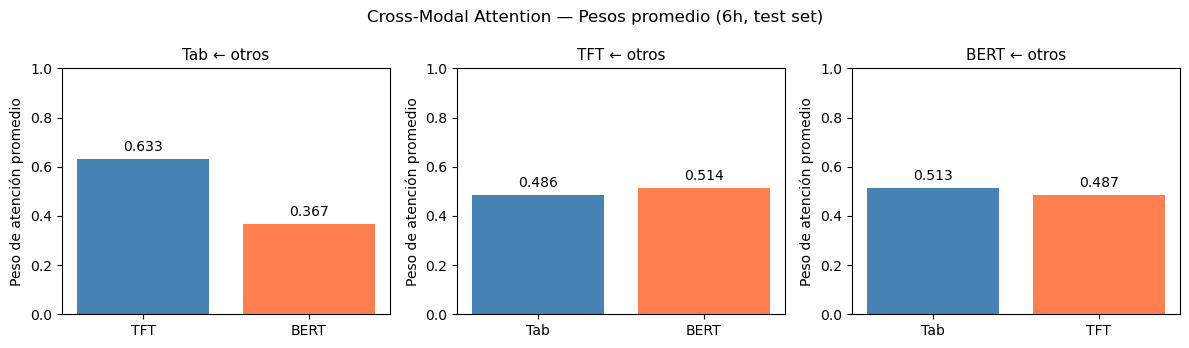

[12:58:06] Guardada: ../experiments/fusion_multimodal/crossattn_weights_6h.png


In [11]:
import matplotlib.pyplot as plt

X_tab, X_tft, X_bert, has_note, y = raw_6h["test"]
loader_te = DataLoader(
    TensorDataset(torch.from_numpy(X_tab), torch.from_numpy(X_tft),
                  torch.from_numpy(X_bert), torch.from_numpy(has_note),
                  torch.from_numpy(y)),
    batch_size=1024
)
models_sistema["6h"].eval()
# Acumular pesos de atención por modalidad
w_tab_all, w_tft_all, w_bert_all = [], [], []
with torch.no_grad():
    for X_tab_b, X_tft_b, X_bert_b, hn_b, _ in loader_te:
        _, aw = models_sistema["6h"](X_tab_b.to(DEVICE), X_tft_b.to(DEVICE), X_bert_b.to(DEVICE), hn_b.to(DEVICE))
        w_tab_all.append(aw["tab"].cpu().numpy())    # [B, 2]: peso sobre (tft, bert)
        w_tft_all.append(aw["tft"].cpu().numpy())    # [B, 2]: peso sobre (tab, bert)
        w_bert_all.append(aw["bert"].cpu().numpy())  # [B, 2]: peso sobre (tab, tft)

w_tab  = np.concatenate(w_tab_all,  axis=0).mean(0)   # [2]
w_tft  = np.concatenate(w_tft_all,  axis=0).mean(0)   # [2]
w_bert = np.concatenate(w_bert_all, axis=0).mean(0)   # [2]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
pairs = [
    ("Tab ← otros",  w_tab,  ["TFT", "BERT"]),
    ("TFT ← otros",  w_tft,  ["Tab", "BERT"]),
    ("BERT ← otros", w_bert, ["Tab", "TFT"]),
]
for ax, (title, w, labels) in zip(axes, pairs):
    bars = ax.bar(labels, w, color=["steelblue", "coral"])
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Peso de atención promedio")
    for bar, val in zip(bars, w):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10)

fig.suptitle("Cross-Modal Attention — Pesos promedio (6h, test set)", fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / "crossattn_weights_6h.png", dpi=150, bbox_inches="tight")
plt.show()
log(f"Guardada: {OUT_DIR / 'crossattn_weights_6h.png'}")

In [12]:
print("=" * 92)
print("  RAMA TABULAR: sistema adoptado (99d sin comprimir) vs ablación (codificador TabNet 32d)")
print("=" * 92)
print(f"{'Horiz.':<8} {'Rama tabular':<26} {'AUROC val':>10} {'AUROC test':>11} {'AUPRC test':>11} {'Sens@90':>9}")
print("-" * 92)
for horizon in ["6h", "12h"]:
    sis,  abl  = res_sistema_test[horizon], res_test[horizon]
    sisv, ablv = res_sistema_val[horizon],  res_val[horizon]
    print(f"{horizon:<8} {'99d sin comprimir (sistema)':<26} {sisv['auroc']:>10.4f} {sis['auroc']:>11.4f} "
          f"{sis['auprc']:>11.4f} {sis['sens_at_spec90']:>9.4f}")
    print(f"{'':<8} {'TabNet 32d (ablación)':<26} {ablv['auroc']:>10.4f} {abl['auroc']:>11.4f} "
          f"{abl['auprc']:>11.4f} {abl['sens_at_spec90']:>9.4f}")
    print(f"{'':<8} {'coste de comprimir':<26} {ablv['auroc']-sisv['auroc']:>+10.4f} "
          f"{abl['auroc']-sis['auroc']:>+11.4f} {abl['auprc']-sis['auprc']:>+11.4f} "
          f"{abl['sens_at_spec90']-sis['sens_at_spec90']:>+9.4f}")
    print("-" * 92)


  RAMA TABULAR: sistema adoptado (99d sin comprimir) vs ablación (codificador TabNet 32d)
Horiz.   Rama tabular                AUROC val  AUROC test  AUPRC test   Sens@90
--------------------------------------------------------------------------------------------
6h       99d sin comprimir (sistema)     0.9114      0.9275      0.7240    0.7638
         TabNet 32d (ablación)          0.8969      0.9122      0.7018    0.7290
         coste de comprimir            -0.0145     -0.0153     -0.0222   -0.0348
--------------------------------------------------------------------------------------------
12h      99d sin comprimir (sistema)     0.8982      0.9264      0.7334    0.7730
         TabNet 32d (ablación)          0.8925      0.9165      0.7246    0.7587
         coste de comprimir            -0.0057     -0.0099     -0.0088   -0.0143
--------------------------------------------------------------------------------------------


In [13]:
for horizon in ["6h", "12h"]:
    # El sistema que reporta la memoria es el de rama tabular sin comprimir
    torch.save(models_sistema[horizon].state_dict(), OUT_DIR / f"fusion_{horizon}.pt")
    torch.save(models[horizon].state_dict(),
               OUT_DIR / f"fusion_ablacion_tabnet32_{horizon}.pt")

results = {
    "architecture": "Fusión multimodal cross-modal: tabular 99d + TFT(64) + Bio_ClinicalBERT(768)",
    "tab_branch": "Vector de 99 características sin comprimir (imputación mediana + z-score de train), "
                  "proyectado por la capa lineal que aprende la red de fusión",
    "val":  res_sistema_val,
    "test": res_sistema_test,
    "ablacion_tabnet32": {
        "tab_branch": "Codificador de TabNet (entrada de final_mapping, 32d), z-scored con train",
        "val": res_val, "test": res_test,
    },
    "platt": res_platt,
    "metricas_calibracion": NOTA_METRICAS,
}
with open(OUT_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))
log("Completado.")


{
  "architecture": "Fusi\u00f3n multimodal cross-modal: tabular 99d + TFT(64) + Bio_ClinicalBERT(768)",
  "tab_branch": "Vector de 99 caracter\u00edsticas sin comprimir (imputaci\u00f3n mediana + z-score de train), proyectado por la capa lineal que aprende la red de fusi\u00f3n",
  "val": {
    "6h": {
      "auroc": 0.9114,
      "auprc": 0.6786,
      "sens_at_spec90": 0.7347,
      "brier": 0.0437,
      "ece": 0.0063,
      "brier_sin_calibrar": 0.1071,
      "ece_sin_calibrar": 0.1537,
      "platt_a": 0.764938,
      "platt_b": -2.212868
    },
    "12h": {
      "auroc": 0.8982,
      "auprc": 0.659,
      "sens_at_spec90": 0.7131,
      "brier": 0.0461,
      "ece": 0.0129,
      "brier_sin_calibrar": 0.1171,
      "ece_sin_calibrar": 0.1776,
      "platt_a": 0.842683,
      "platt_b": -2.198939
    }
  },
  "test": {
    "6h": {
      "auroc": 0.9275,
      "auprc": 0.724,
      "sens_at_spec90": 0.7638,
      "brier": 0.0406,
      "ece": 0.0075,
      "brier_sin_calibrar": 

## Ablación leave-one-out de modalidades

Entrena la red de fusión quitando una modalidad cada vez (código en
`ablacion_leave_one_out.py`) y compara con la configuración completa, con idénticos
hiperparámetros, semilla y particiones. Responde: ¿aporta cada modalidad información
que las otras dos no tengan ya?

Notas metodológicas:

- **`has_note` se elimina junto con la rama de texto**: indica si existe informe de
  radiología, así que mantenerlo dejaría un proxy de la modalidad textual dentro de la
  variante "sin texto". Al viajar concatenado a la rama tabular, también desaparece en
  la variante "sin tabular".
- **Con dos modalidades, K/V es una secuencia de un solo token**, de modo que el softmax
  de la atención devuelve peso 1,0 por construcción: el bloque deja de seleccionar entre
  fuentes y se reduce a una mezcla residual aprendida. Es una ablación válida de
  *modalidad*, no de *mecanismo*.
- La configuración completa se reentrena como control bajo el mismo protocolo, por lo
  que sus métricas pueden diferir ligeramente de las del modelo principal de arriba.

In [14]:
exec(open("ablacion_leave_one_out.py").read())

df_loo_6h  = run_leave_one_out(fusion_6h,  get_pw(fusion_6h),  "[6h]")
df_loo_12h = run_leave_one_out(fusion_12h, get_pw(fusion_12h), "[12h]")
df_loo_6h.to_csv(OUT_DIR / "ablacion_loo_6h.csv", index=False)
df_loo_12h.to_csv(OUT_DIR / "ablacion_loo_12h.csv", index=False)
print(df_loo_6h.to_string(index=False))
print(df_loo_12h.to_string(index=False))


=== Completa (tab + tft + bert) [6h] ===


    época   0  AUROC val = 0.8852  (mejor 0.8852)


    época   5  AUROC val = 0.8945  (mejor 0.8979)


    época  10  AUROC val = 0.8903  (mejor 0.8985)


    época  15  AUROC val = 0.8810  (mejor 0.8985)


...

    época   0  AUROC val = 0.8781  (mejor 0.8781)


    época   5  AUROC val = 0.8837  (mejor 0.8917)


    época  10  AUROC val = 0.8888  (mejor 0.8917)


    época  15  AUROC val = 0.8897  (mejor 0.8917)


  -> test AUROC 0.9193 | AUPRC 0.7242 | Sens@Esp90 0.7492 | Brier 0.1136 | ECE 0.1972
              configuracion  modalidades  auroc_val  auroc_test  auprc_test  sens_esp90  brier_test_sin_calibrar  ece_test_sin_calibrar  n_params  delta_auroc_test  delta_auprc_test  delta_sens_esp90  delta_brier_test_sin_calibrar  delta_ece_test_sin_calibrar
Completa (tab + tft + bert) tab+tft+bert     0.8985      0.9145      0.7010      0.7348                   0.1217                 0.1793    558977            0.0000            0.0000            0.0000                         0.0000                       0.0000
           Sin texto (bert)      tab+tft     0.8376      0.8628      0.6465      0.6623                   0.0983                 0.1976    311297           -0.0517           -0.0545           -0.0725                        -0.0234                       0.0183
          Sin vitales (tft)     tab+bert     0.8374      0.8655      0.4878      0.5667                   0.1993                 0.280

### Escalera de la rama tabular

La ablación anterior compara *quitar* la rama tabular contra mantenerla con el codificador
de TabNet. Falta el tercer peldaño: mantenerla con el vector de 99 características sin
comprimir. Aquí se repite el mismo driver sobre `raw_6h` / `raw_12h`, de modo que las tres
cifras salen de una única familia de ejecuciones y son directamente comparables:

| Peldaño | De dónde sale |
|---|---|
| Sin rama tabular | fila «Sin tabular» de cualquiera de las dos tandas |
| Tabular = codificador TabNet (32 dim) | fila «Completa» de la tanda con `fusion_*` |
| Tabular = vector crudo (99 dim) | fila «Completa» de esta tanda con `raw_*` |

**Control de calidad**: la fila «Sin tabular» debe reproducirse *exactamente* entre ambas
tandas. Esa configuración no instancia la rama tabular —`LeaveOneOutFusion` solo crea las
proyecciones de las modalidades presentes—, así que `tab_dim` (99 frente a 32) no consume
números aleatorios ni altera la arquitectura, y el resto de tensores de entrada son los
mismos. Cualquier discrepancia indicaría una fuga entre configuraciones.

In [15]:
df_loo_raw_6h  = run_leave_one_out(raw_6h,  get_pw(raw_6h),  "[6h crudo]")
df_loo_raw_12h = run_leave_one_out(raw_12h, get_pw(raw_12h), "[12h crudo]")
df_loo_raw_6h.to_csv(OUT_DIR / "ablacion_loo_raw_6h.csv", index=False)
df_loo_raw_12h.to_csv(OUT_DIR / "ablacion_loo_raw_12h.csv", index=False)
print(df_loo_raw_6h.to_string(index=False))
print(df_loo_raw_12h.to_string(index=False))

# Control de calidad: "Sin tabular" debe coincidir entre ambas tandas.
for h, dr, dt in [("6h", df_loo_raw_6h, df_loo_6h), ("12h", df_loo_raw_12h, df_loo_12h)]:
    a = dr.loc[dr.configuracion.str.startswith("Sin tabular")].iloc[0]
    b = dt.loc[dt.configuracion.str.startswith("Sin tabular")].iloc[0]
    ok = all(a[c] == b[c] for c in ("auroc_val", "auroc_test", "auprc_test", "sens_esp90"))
    print(f"  {h}: sin tabular  crudo={a.auroc_test:.4f}  tabnet={b.auroc_test:.4f}  "
          f"-> {'COINCIDE' if ok else 'DIFIERE'}")


=== Completa (tab + tft + bert) [6h crudo] ===


    época   0  AUROC val = 0.9035  (mejor 0.9035)


    época   5  AUROC val = 0.9060  (mejor 0.9118)


    época  10  AUROC val = 0.8994  (mejor 0.9118)


  -> test AUROC 0.9311 | AUPRC 0.7298 | Sens@Esp90 0.7739 | Brier 0.1130 | ECE 0.1963

=== Sin texto (bert) [6h crudo] ===


...

    época   0  AUROC val = 0.8781  (mejor 0.8781)


    época   5  AUROC val = 0.8837  (mejor 0.8917)


    época  10  AUROC val = 0.8888  (mejor 0.8917)


    época  15  AUROC val = 0.8897  (mejor 0.8917)


  -> test AUROC 0.9193 | AUPRC 0.7242 | Sens@Esp90 0.7492 | Brier 0.1136 | ECE 0.1972
              configuracion  modalidades  auroc_val  auroc_test  auprc_test  sens_esp90  brier_test_sin_calibrar  ece_test_sin_calibrar  n_params  delta_auroc_test  delta_auprc_test  delta_sens_esp90  delta_brier_test_sin_calibrar  delta_ece_test_sin_calibrar
Completa (tab + tft + bert) tab+tft+bert     0.9118      0.9311      0.7298      0.7739                   0.1130                 0.1963    567553            0.0000            0.0000            0.0000                         0.0000                       0.0000
           Sin texto (bert)      tab+tft     0.8622      0.8854      0.6697      0.7014                   0.1023                 0.1998    319873           -0.0457           -0.0601           -0.0725                        -0.0107                       0.0035
          Sin vitales (tft)     tab+bert     0.8804      0.9047      0.5908      0.6754                   0.1359                 0.219